Basic Understandings about the data from the reading the descriptions:


1. Information about the customer,
2. Product purchased,
3. Ticket type,
4. Ticket channel,
5. Ticket status,
6. other relevant details (Need to check).

Feature Descriptions:


1. Ticket ID: A unique identifier for each ticket.
2. Customer Name: The name of the customer who raised the ticket.
3. Customer Email: The email address of the customer.
4. Customer Age: The age of the customer.
5. Customer Gender: The gender of the customer.
6. Product Purchased: The tech product purchased by the customer.
7. Date of Purchase: The date when the product was purchased.
8. Ticket Type: The type of ticket (e.g., technical issue, billing inquiry, product inquiry).
9. Ticket Subject: The subject/topic of the ticket.
10. Ticket Description: The description of the customer's issue or inquiry.
Ticket Status: The status of the ticket (e.g., open, closed, pending customer response).
11. Resolution: The resolution or solution provided for closed tickets.
Ticket Priority: The priority level assigned to the ticket (e.g., low, medium, high, critical).
12. Ticket Channel: The channel through which the ticket was raised (e.g., email, phone, chat, social media).
13. First Response Time: The time taken to provide the first response to the customer.
14. Time to Resolution: The time taken to resolve the ticket.
Customer Satisfaction Rating: The customer's satisfaction rating for closed tickets (on a scale of 1 to 5).

Column Details: Number of Columns - 17

String dType - 10 columns
DateTime dType - 3 columns
Decimal/Float dType - 1 column
Other dTypes - 3 Columns

1. TicketID - Float dType  
2. CustomerName - String dType
3. CustomerEmail - String dType
4. CustomerAge - Float dType
5. CustomerGender - String dType
6. ProductPurchased - String dType
7. DateofPurchase - DateTime dType
8. TicketType - String dType
9. TicketSubject - String dType
10. TicketDescription - String dType
11. TicketStatus - String dType
12. Resolution - String dType (67 % missing data)
13. Ticket Priority - String dType
14. Ticket Channel - String dType
15. First Response Time - DateTime dType
16. Time to Resolution - DateTime dType
17. Customer Satisfaction Rating - Float dType (1-5)

# Technical Report: NLP Exploratory Data Analysis

1. Document Collection Overview
This dataset consists of 8,469 customer support tickets. For NLP modeling purposes, the primary corpus is the `Ticket Description` field, supplemented by `Ticket Subject` and `Resolution` metadata.

2. Textual Characteristics & Corpus Metrics
- Vocabulary Quality: The presence of non-ASCII characters (196 instances) suggests a need for encoding standardization or language filtering.
- Template Patterns: Preliminary observation shows the frequent use of placeholders like `{product_purchased}`, indicating that a portion of the data may be synthetically generated or based on strict templates.
- Metadata Integration: The `Ticket Type` and `Ticket Subject` provide high-value labels for supervised text classification tasks.

3. NLP-Specific Data Quality Issues
- External Metadata: Some descriptions contain social media handles and timestamps that are irrelevant to the core support issue and should be removed during preprocessing.
- Sparsity: The `Resolution` text field is 67% null, making it a target for text generation rather than a reliable feature for classification without significant imputation.


In [6]:
# Import the necessary modules 
import kagglehub
import pandas as pd
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams
from gensim.parsing.preprocessing import STOPWORDS
import shutil

# 1. Get the current directory and calculate the root (2 levels up)
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..', '..'))

# 2. Change the actual working directory of the script/notebook
os.chdir(root_path)

# 3. Add to sys.path so you can still import your local modules
if root_path not in sys.path:
    sys.path.append(root_path)

# Verification
print(f"Old directory: {current_dir}")
print(f"New current directory: {os.getcwd()}")

reports_dir = os.path.join(root_path, 'reports')
figures_dir = os.path.join(reports_dir, 'figures')
tables_dir = os.path.join(reports_dir, 'tables')
os.makedirs(figures_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)
print(f"Figures will be saved to: {figures_dir}")
print(f"Tables will be saved to: {tables_dir}")


Old directory: e:\Study\Bristol\IATA\Group_Project\Final\EMATM0067_2025_TB-2-g43
New current directory: e:\Study\Bristol\IATA\Group_Project
Figures will be saved to: e:\Study\Bristol\IATA\Group_Project\reports\figures
Tables will be saved to: e:\Study\Bristol\IATA\Group_Project\reports\tables


In [ ]:

current_dir = os.getcwd()
print(f"current dir is: {current_dir}")

if current_dir.endswith("EMATM0067_2025_TB-2-g43"):
    root_path = current_dir
elif current_dir.endswith("01_eda"):
    root_path = os.path.abspath(os.path.join(current_dir, "..", ".."))

download_path_dir = os.path.join(root_path, "data", "raw")
os.makedirs(download_path_dir, exist_ok=True) 

cache_path = kagglehub.dataset_download("suraj520/customer-support-ticket-dataset")
file_name = "customer_support_tickets.csv"
cached_csv_path = os.path.join(cache_path, file_name)

final_csv_path = os.path.join(download_path_dir, file_name)
shutil.copy(cached_csv_path, final_csv_path)

print(f"file save to: {final_csv_path}")

current dir is: e:\Study\Bristol\IATA\Group_Project
file save to: E:\Study\Bristol\IATA\Group_Project\Final\EMATM0067_2025_TB-2-g43\data\raw\customer_support_tickets.csv


In [8]:
from src.utils.Utils import store_dataset

# Define your project's raw data folder
download_path_dir = os.path.join(root_path, "data", "raw")
os.makedirs(download_path_dir, exist_ok=True) 

# Download the dataset (Kaggle saves this to the cache)
path = kagglehub.dataset_download("suraj520/customer-support-ticket-dataset")
print(path)
file_name = "customer_support_tickets.csv"

# Store the dataset using your custom utility
store_dataset(
    source_path=path,        
    target_directory=download_path_dir, 
    target_filename=file_name           
)

# Define final path for reading/printing
final_csv_path = os.path.join(download_path_dir, file_name)

C:\Users\96321\.cache\kagglehub\datasets\suraj520\customer-support-ticket-dataset\versions\1
An unexpected error occurred: [WinError 183] 当文件已存在时，无法创建该文件。: 'E:\\Study\\Bristol\\IATA\\Group_Project\\Final\\EMATM0067_2025_TB-2-g43\\data\\raw\\customer_support_tickets.csv'


In [9]:
# Load the data 
df = pd.read_csv(final_csv_path)
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [10]:
# Check the columns in the dataset
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [11]:
# basic description about the dataset
df.describe()

,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.000000,8469.000000,2769.000000
mean,4235.000000,44.026804,2.991333
std,2444.934048,15.296112,1.407016
min,1.000000,18.000000,1.000000
25%,2118.000000,31.000000,2.000000
50%,4235.000000,44.000000,3.000000
75%,6352.000000,57.000000,4.000000
max,8469.000000,70.000000,5.000000


In [12]:
# Get the columns and it's dtype
df.dtypes

Ticket ID                         int64
Customer Name                    object
Customer Email                   object
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution                       object
Ticket Priority                  object
Ticket Channel                   object
First Response Time              object
Time to Resolution               object
Customer Satisfaction Rating    float64
dtype: object

In [13]:
# Identify most frequent 'Ticket Subjects' as label candidates
display(df['Ticket Subject'].value_counts().head(10).to_frame())

,count
Ticket Subject,
Refund request,576
Software bug,574
Product compatibility,567
Delivery problem,561
Hardware issue,547
Battery life,542
Network problem,539
Installation support,530
Product setup,529


In [14]:
# Check for placeholder leakage
placeholders = df['Ticket Description'].str.contains('{').sum()
print(f"\nTickets containing template placeholders: {placeholders}")


Tickets containing template placeholders: 8469


In [15]:
# Defining the categorical columns for analysis
cat_cols = ['Ticket Type', 'Ticket Status', 'Ticket Priority', 'Ticket Channel', "Product Purchased", "Customer Gender"]

# Displaying frequency tables
print("--- Categorical Feature Distributions ---")
for col in cat_cols:
    display(df[col].value_counts().to_frame())

--- Categorical Feature Distributions ---


,count
Ticket Type,
Refund request,1752
Technical issue,1747
Cancellation request,1695
Product inquiry,1641
Billing inquiry,1634


,count
Ticket Status,
Pending Customer Response,2881
Open,2819
Closed,2769


,count
Ticket Priority,
Medium,2192
Critical,2129
High,2085
Low,2063


,count
Ticket Channel,
Email,2143
Phone,2132
Social media,2121
Chat,2073


,count
Product Purchased,
Canon EOS,240
GoPro Hero,228
Nest Thermostat,225
Amazon Echo,221
Philips Hue Lights,221
LG Smart TV,219
Sony Xperia,217
Roomba Robot Vacuum,216
Apple AirPods,213


,count
Customer Gender,
Male,2896
Female,2887
Other,2686


In [16]:
# Print some sample ticket descriptions
target_description = df['Ticket Description']

for i in range(2, 12):
  print(f"--- Random Ticket Description {len(target_description) // i} ---")
  print(target_description[len(target_description) // i])
  print("\n")

--- Random Ticket Description 4234 ---
I'm unable to access my {product_purchased} account. It keeps displaying an 'Invalid Credentials' error, even though I'm using the correct login information. How can I regain access to my account? I need assistance as soon as possible because it's affecting my work and productivity.


--- Random Ticket Description 2823 ---
I'm having an issue with the {product_purchased}. Please assist. I will contact you if I need a replacement.

[2]: (1) The vendor does not give you an authorization that a valid invoice is available for I've reviewed the troubleshooting steps on the official support website, but they didn't resolve the problem.


--- Random Ticket Description 2117 ---
I'm having an issue with the {product_purchased}. Please assist. We're in trouble because there is no way I can turn down at my last chance. Please try again. Thank you to everyone who has provided helpful info. I I've tried different settings and configurations on my {product_purc

C:\Users\96321\AppData\Local\Temp\ipykernel_23564\478985970.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, ax=axes[i], palette='viridis', order=df[col].value_counts().index)
C:\Users\96321\AppData\Local\Temp\ipykernel_23564\478985970.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, ax=axes[i], palette='viridis', order=df[col].value_counts().index)
C:\Users\96321\AppData\Local\Temp\ipykernel_23564\478985970.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, ax=axes[i], palette='vi

Saved figure: eda_thiruvelap_fig_11.png


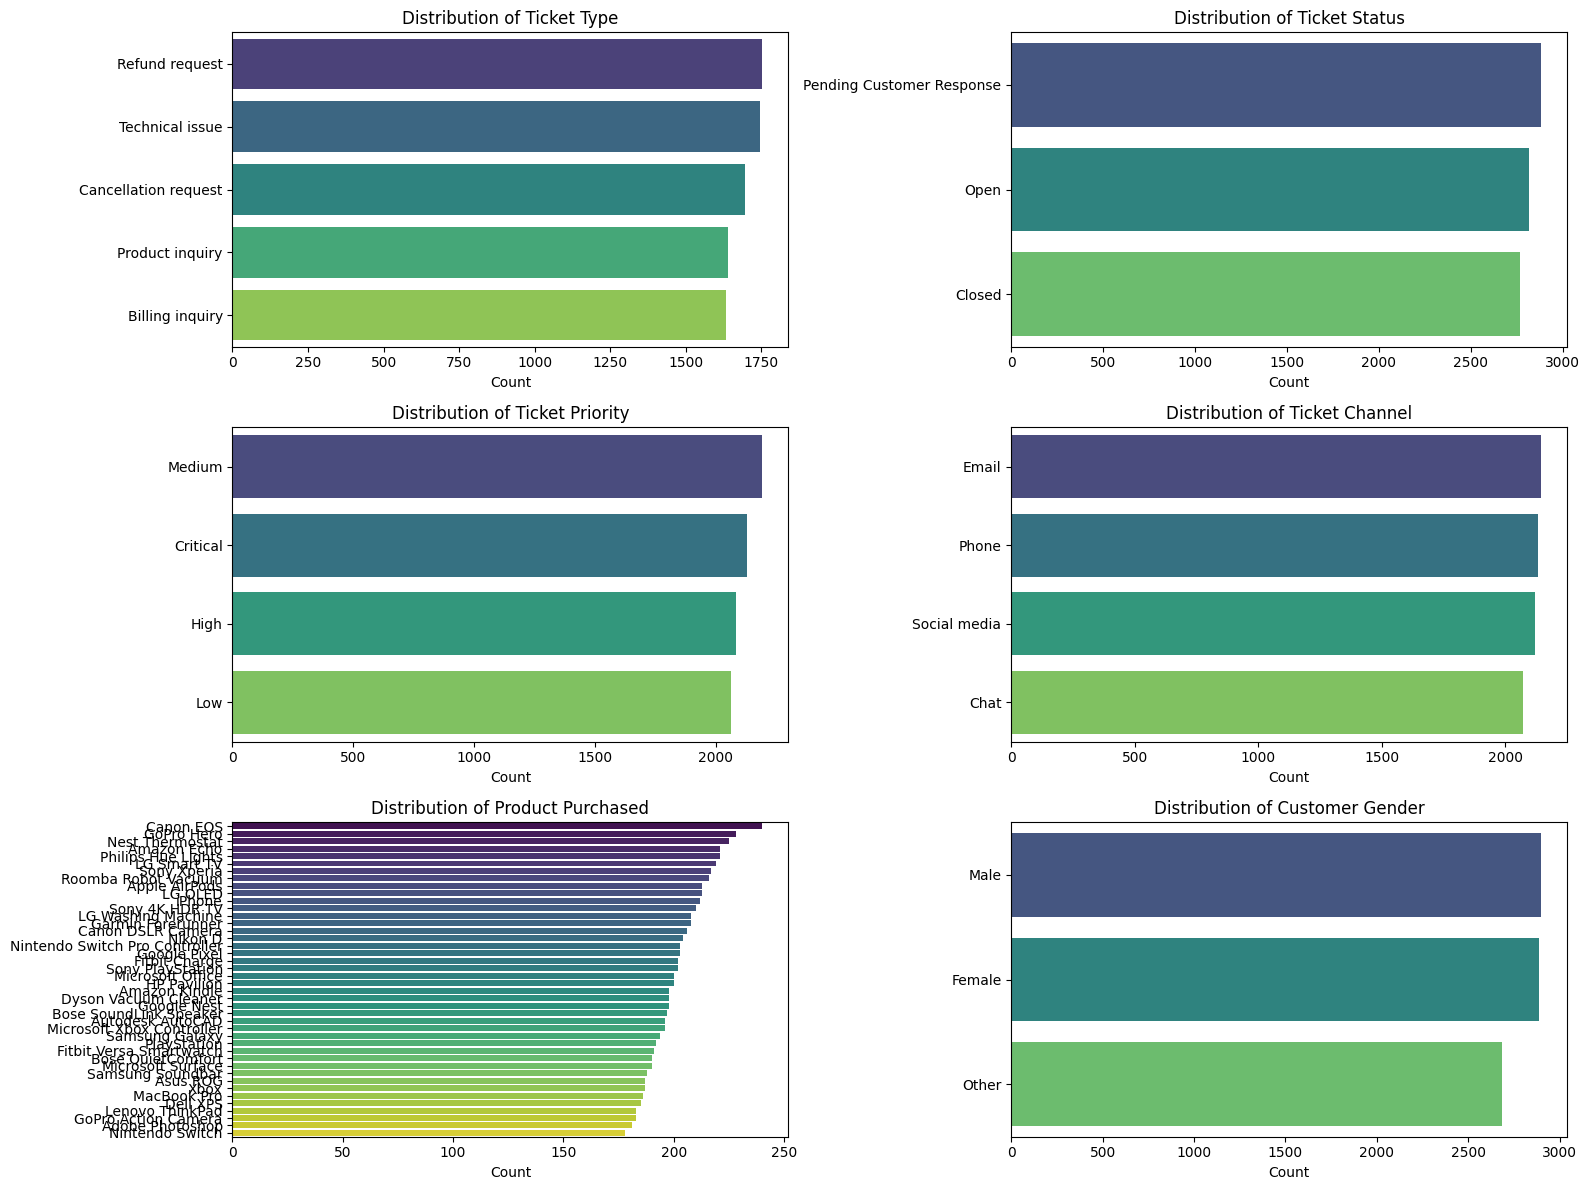

In [17]:
# Visualization of the distributions of categorial columns 
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

cat_cols = ['Ticket Type', 'Ticket Status', 'Ticket Priority', 'Ticket Channel', "Product Purchased", "Customer Gender"]

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, y=col, ax=axes[i], palette='viridis', order=df[col].value_counts().index)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'eda_thiruvelap_categorical_distributions.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'eda_thiruvelap_fig_11.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: eda_thiruvelap_fig_11.png")

plt.show()

Saved figure: eda_thiruvelap_fig_12.png


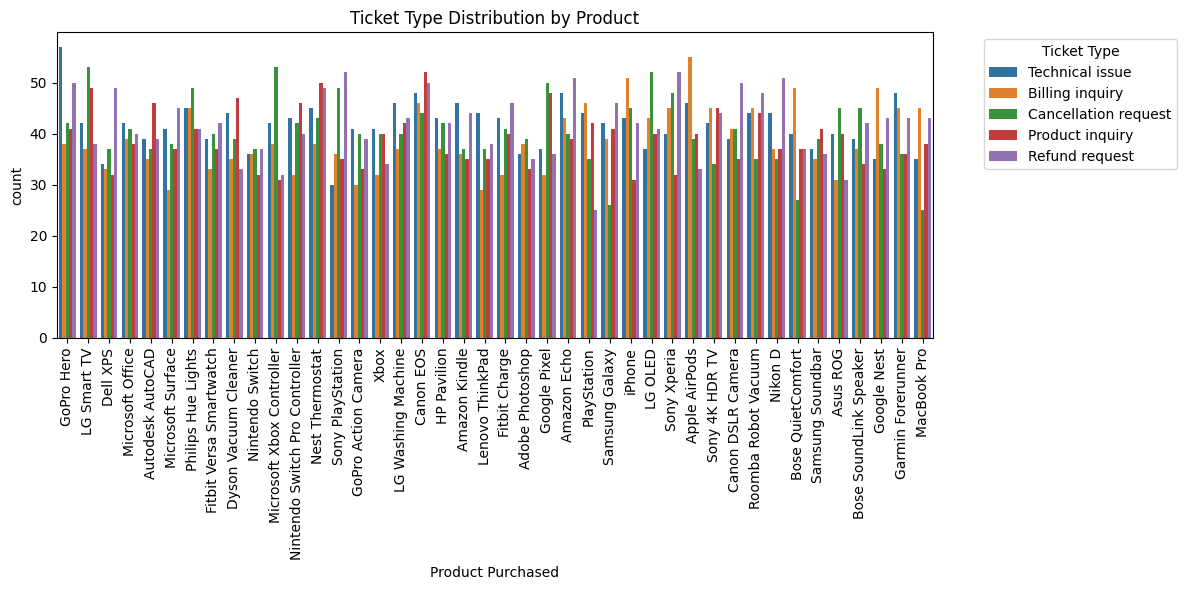

In [18]:
# Relationship between Product and Ticket Type
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Product Purchased', hue='Ticket Type')
plt.title('Ticket Type Distribution by Product')
plt.xticks(rotation=90)
plt.legend(title='Ticket Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'eda_thiruvelap_tickettype_by_product.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'eda_thiruvelap_fig_12.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: eda_thiruvelap_fig_12.png")

plt.show()

In [19]:
# Inspecting raw samples to identify common NLP noise
# Checking the Resolution text availability
res_nulls = df['Resolution'].isnull().sum()
print(f"Missing Resolutions: {res_nulls} ({res_nulls/len(df)*100:.2f}%)")

# Quick view of non-null resolutions
display(df[df['Resolution'].notnull()][['Resolution']].head(2))

Missing Resolutions: 5700 (67.30%)


,Resolution
2,Case maybe show recently my computer follow.
3,Try capital clearly never color toward story.


In [20]:
# Count the values of individual tickets distributions accross the ticket type and ticket subject
ticket_type_value_count =  df['Ticket Type'].value_counts().to_frame()
ticket_subject_value_count = df['Ticket Subject'].value_counts().to_frame()

print(f"Ticket Type Value Counts:\n{ticket_type_value_count}\n")
print(f"Ticket Subject Value Counts:\n{ticket_subject_value_count}\n")

Ticket Type Value Counts:
                      count
Ticket Type                
Refund request         1752
Technical issue        1747
Cancellation request   1695
Product inquiry        1641
Billing inquiry        1634

Ticket Subject Value Counts:
                          count
Ticket Subject                 
Refund request              576
Software bug                574
Product compatibility       567
Delivery problem            561
Hardware issue              547
Battery life                542
Network problem             539
Installation support        530
Product setup               529
Payment issue               526
Product recommendation      517
Account access              509
Peripheral compatibility    496
Data loss                   491
Cancellation request        487
Display issue               478



C:\Users\96321\AppData\Local\Temp\ipykernel_23564\2497408928.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\96321\AppData\Local\Temp\ipykernel_23564\2497408928.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Saved figure: eda_thiruvelap_fig_15.png


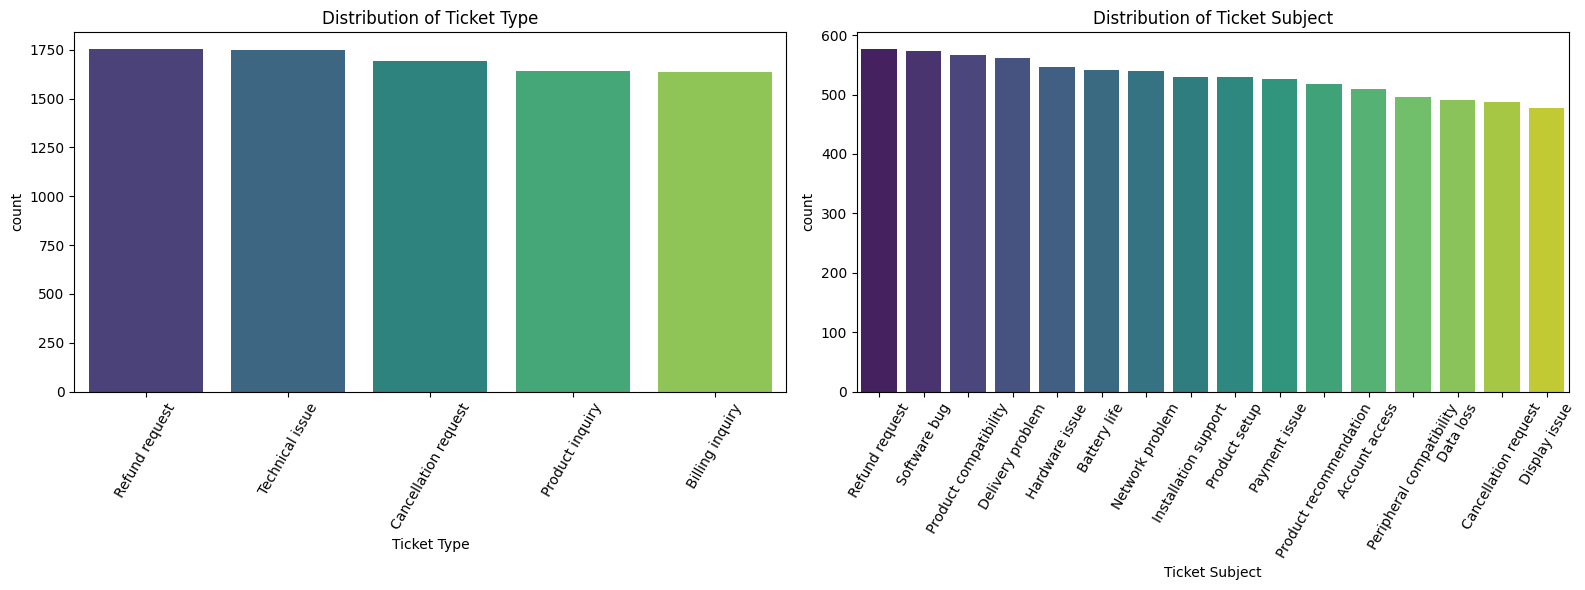

In [21]:
# Bar plot of the counts of tickets againest ticket types and ticket subject 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cols = ['Ticket Type', 'Ticket Subject']
for i, col in enumerate(cols):
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        palette='viridis',
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'eda_thiruvelap_ticket_type_subject_distribution.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'eda_thiruvelap_fig_15.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: eda_thiruvelap_fig_15.png")

plt.show()

Ticket Priority       Critical  High  Low  Medium
Ticket Type                                      
Billing inquiry            420   382  398     434
Cancellation request       423   398  414     460
Product inquiry            403   399  398     441
Refund request             444   448  440     420
Technical issue            439   458  413     437
Saved figure: eda_thiruvelap_fig_16.png


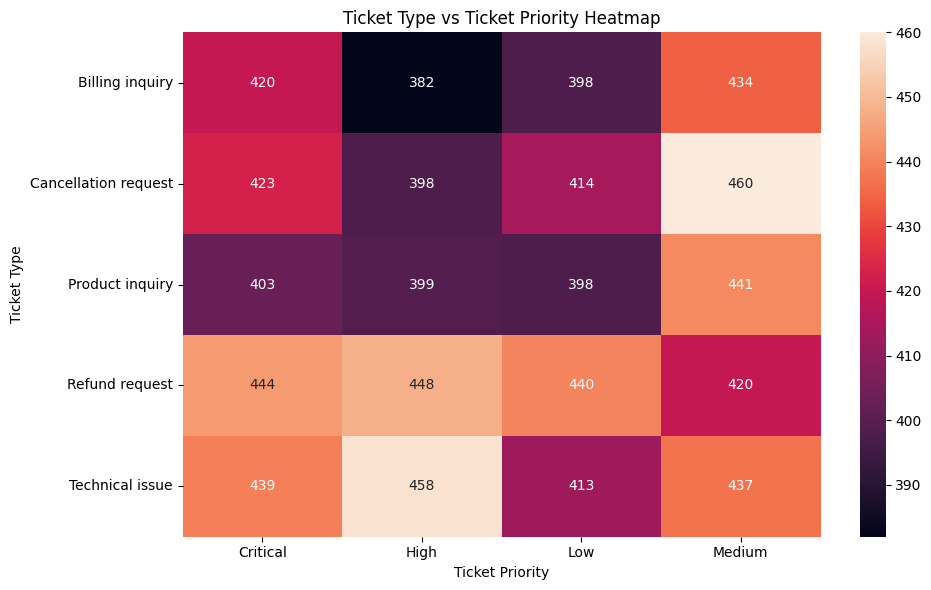

In [22]:
# Cross map relationship between the ticket type and ticket priority
ct = pd.crosstab(df['Ticket Type'], df['Ticket Priority'])
print(ct)

# heatmap of the relationship
plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt='d')
plt.title('Ticket Type vs Ticket Priority Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'eda_thiruvelap_tickettype_priority_heatmap.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'eda_thiruvelap_fig_16.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: eda_thiruvelap_fig_16.png")

plt.show()

Ticket Type        Billing inquiry  Cancellation request  Product inquiry  \
Product Purchased                                                           
Adobe Photoshop                 38                    39               33   
Amazon Echo                     43                    40               39   
Amazon Kindle                   36                    37               35   
Apple AirPods                   55                    39               40   
Asus ROG                        31                    45               40   

Ticket Type        Refund request  Technical issue  
Product Purchased                                   
Adobe Photoshop                35               36  
Amazon Echo                    51               48  
Amazon Kindle                  44               46  
Apple AirPods                  33               46  
Asus ROG                       31               40  
Saved figure: eda_thiruvelap_fig_17.png


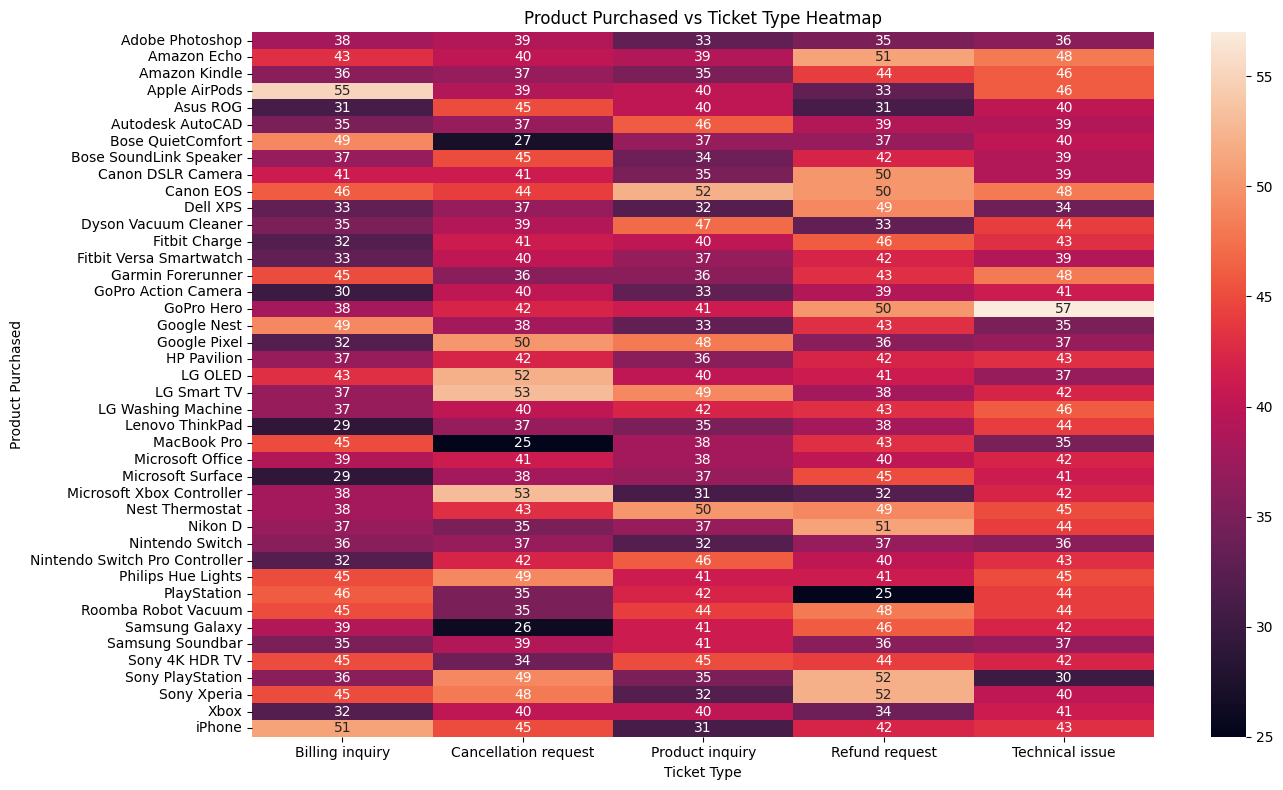

In [23]:
# Cross map relationship between the ticket type and product purchased 
ct_product = pd.crosstab(df['Product Purchased'], df['Ticket Type'])
print(ct_product.head())

# heatmap of the relationship 
plt.figure(figsize=(14, 8))
sns.heatmap(ct_product, annot=True, fmt='d')
plt.title('Product Purchased vs Ticket Type Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'eda_thiruvelap_product_tickettype_heatmap.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'eda_thiruvelap_fig_17.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: eda_thiruvelap_fig_17.png")

plt.show()

### EDA ANALYSIS - CONCLUSIONS

- Textual Characteristics & Corpus Metrics

* Ticket Description Lengths: Mean ~46 words. Distribution is bell-shaped.
* Template Patterns: 100% of tickets contain placeholders like `{product_purchased}`, indicating synthetic generation.
* Top Ticket Subjects: "Refund request", "Software bug", and "Product compatibility" are among the most frequent.

- Categorical Feature Analysis
* Balanced Distribution: Ticket types (Technical, Billing, Refund, etc.) are almost perfectly balanced (~1600-1700 each).
* Channel Neutrality: Users reach out via Email, Phone, Chat, and Social Media with almost equal frequency.
* Cross-Tabulation Insights: Heatmaps show that Priority and Channel are evenly distributed across all Ticket Types, suggesting no bias in how different issue types are reported or prioritized.

- NLP-Specific Data Quality Issues
* Resolution Sparsity: 67.30% null values.
* Noise: Descriptions contain ZIP codes, social media handles (e.g., @realDonaldTrump), and timestamps that act as noise for NLP models.
* Redundancy: Sentence-level duplication within single descriptions was observed.

### ANALYSING TICKET DESCRIPTION COLUMN 

In [24]:
## Word count and chatacter count in the text colums
df['desc_len'] = df['Ticket Description'].str.len()
df['word_count'] = df['Ticket Description'].str.split(' ').str.len()

display(df[['desc_len', 'word_count']].describe())

,desc_len,word_count
count,8469.000000,8469.000000
mean,289.821939,45.253631
std,43.593954,8.625297
min,151.000000,21.000000
25%,273.000000,41.000000
50%,298.000000,47.000000
75%,318.000000,51.000000
max,397.000000,63.000000


Saved figure: eda_thiruvelap_fig_19.png


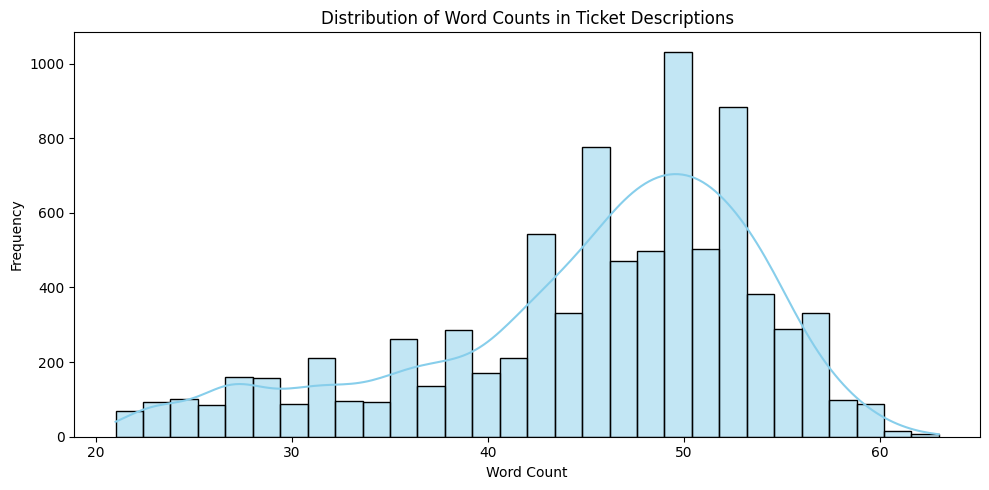

In [25]:
# Visualize the distribution of ticket lengths
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Word Counts in Ticket Descriptions')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'eda_thiruvelap_wordcount_distribution.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'eda_thiruvelap_fig_19.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: eda_thiruvelap_fig_19.png")

plt.show()

C:\Users\96321\AppData\Local\Temp\ipykernel_23564\4177737509.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Saved figure: eda_thiruvelap_fig_20.png


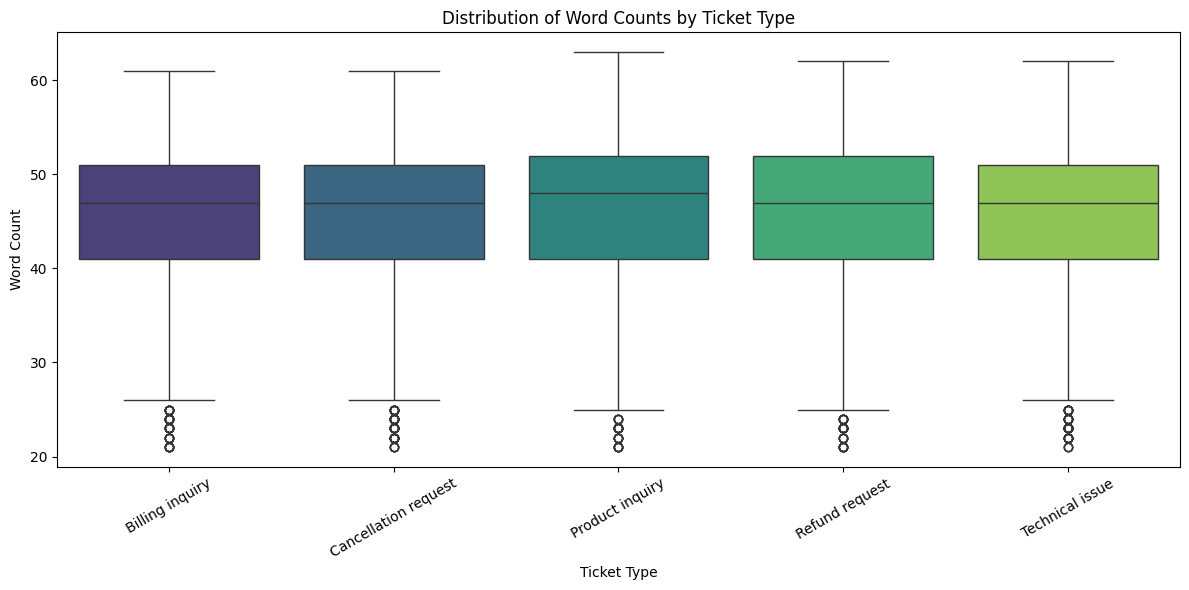

In [26]:
# Distribution of words respect to the ticket type  
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x='Ticket Type',
    y='word_count',
    palette='viridis',
    order=df.groupby('Ticket Type')['word_count'].mean().index
)
plt.title('Distribution of Word Counts by Ticket Type')
plt.xlabel('Ticket Type')
plt.ylabel('Word Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'eda_thiruvelap_wordcount_by_tickettype.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'eda_thiruvelap_fig_20.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: eda_thiruvelap_fig_20.png")

plt.show()

In [27]:
# Unique word analysis accross the entire corpus 
def unique_word_ratio(text):
    words = text.lower().split(" ")
    return len(set(words)) / len(words) if words else 0

df["unique_word_ratio"] = df["Ticket Description"].apply(unique_word_ratio)
df["unique_word_ratio"].groupby(df["Ticket Type"]).describe()

,count,mean,std,min,25%,50%,75%,max
Ticket Type,,,,,,,,
Billing inquiry,1634.0,0.844320,0.065031,0.472727,0.807692,0.847826,0.886792,1.000000
Cancellation request,1695.0,0.848073,0.064031,0.540541,0.812500,0.852941,0.891304,1.000000
Product inquiry,1641.0,0.842889,0.063054,0.585366,0.807692,0.846154,0.886364,0.978723
Refund request,1752.0,0.845707,0.062279,0.416667,0.811321,0.851064,0.886364,0.979167
Technical issue,1747.0,0.841677,0.066992,0.357143,0.808511,0.846154,0.884615,1.000000


In [28]:
# Bi-gram and Tri-gram words analysis 
def get_top_n_words(n=10):
    wnl = WordNetLemmatizer()
    results = {}
    for ticket_type in df['Ticket Type'].unique():
        # Combine all descriptions for this type and split into words
        words = ' '.join(df[df['Ticket Type'] == ticket_type]['Ticket Description']).lower().split()

        # Getting count of bi-grams and tri-grams
        count_bigrams = Counter(ngrams(words, 2)).most_common(10)
        count_trigrams = Counter(ngrams(words, 3)).most_common(10)

        # Filter out very short words or common symbols if needed
        words = [w for w in words if len(w) > 3 and w not in STOPWORDS]

        results[ticket_type] = {
            "bigrams": count_bigrams,
            "trigrams": count_trigrams,
            "countCommonWords": Counter(words).most_common(n)
        }
    return results

top_words_by_type = get_top_n_words(10)

# print the words
for t_type, words in top_words_by_type.items():
    print(f"{t_type}:")
    print(f"Bigrams: {words['bigrams']}")
    print(f"Trigrams: {words['trigrams']}")
    print(f"Common Words: {words['countCommonWords']}\n")

Technical issue:
Bigrams: [(('the', '{product_purchased}.'), 1432), (('with', 'the'), 1338), (('issue', 'with'), 1330), (("i'm", 'having'), 1318), (('an', 'issue'), 1307), (('having', 'an'), 1293), (('please', 'assist.'), 1290), (('{product_purchased}.', 'please'), 1276), (('the', 'issue'), 635), (('my', '{product_purchased}'), 481)]
Trigrams: [(('an', 'issue', 'with'), 1299), (('issue', 'with', 'the'), 1294), (('having', 'an', 'issue'), 1293), (("i'm", 'having', 'an'), 1281), (('with', 'the', '{product_purchased}.'), 1271), (('the', '{product_purchased}.', 'please'), 1269), (('{product_purchased}.', 'please', 'assist.'), 1268), (('but', 'the', 'issue'), 343), (('my', '{product_purchased},', 'but'), 252), (('the', 'issue', 'persists.'), 247)]
Common Words: [('issue', 2158), ('{product_purchased}.', 1674), ('having', 1345), ('assist.', 1291), ("i've", 1219), ('{product_purchased}', 714), ('{product_purchased},', 467), ('product', 314), ('data', 276), ('software', 271)]

Billing inquiry:

C:\Users\96321\AppData\Local\Temp\ipykernel_23564\337533438.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=group_sorted, ax=axes[i], palette='viridis')
C:\Users\96321\AppData\Local\Temp\ipykernel_23564\337533438.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=group_sorted, ax=axes[i], palette='viridis')
C:\Users\96321\AppData\Local\Temp\ipykernel_23564\337533438.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=group_sorted, ax=axes[i], palette='virid

Saved figure: eda_thiruvelap_fig_23.png


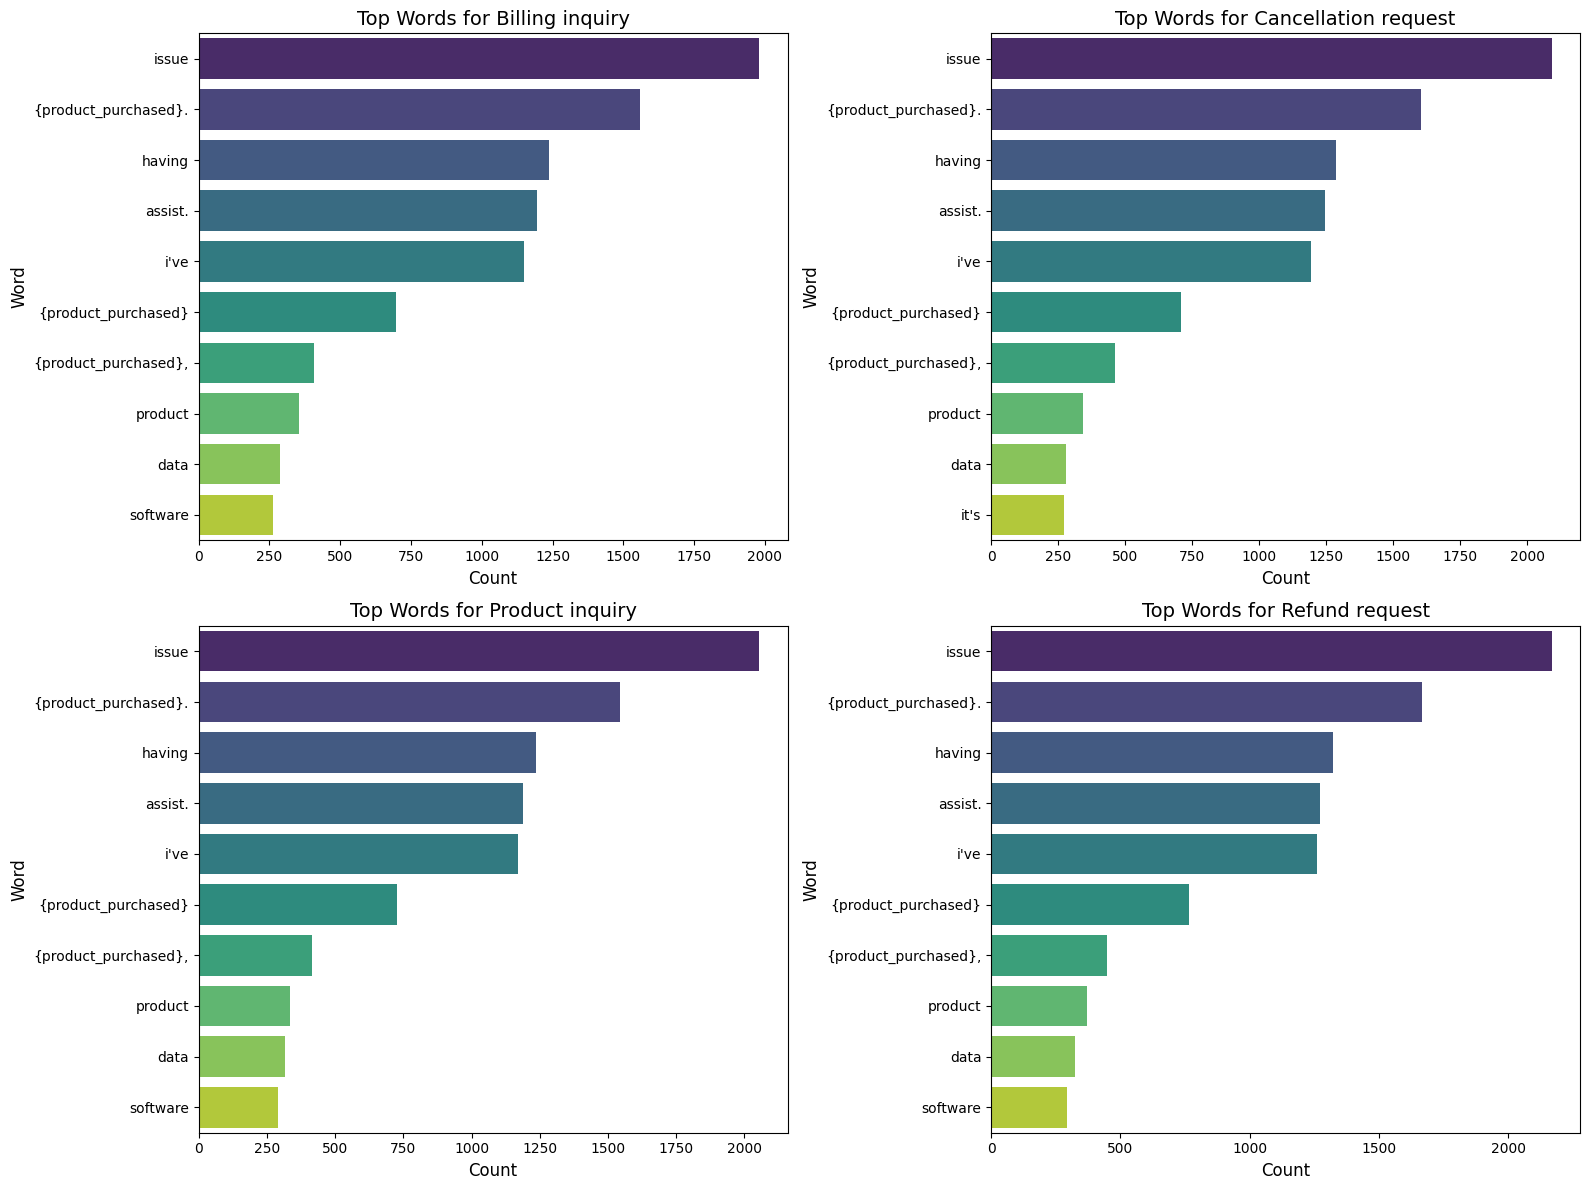

In [29]:
# count and plot the common words 
plot_data = []
for ticket_type, words in top_words_by_type.items():
    for word, count in words['countCommonWords']:
        plot_data.append({'Ticket Type': ticket_type, 'Word': word, 'Count': count})

top_words_df = pd.DataFrame(plot_data)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (ticket_type, group) in enumerate(top_words_df.groupby('Ticket Type')):
    if i >= min(len(top_words_df['Ticket Type'].unique()), len(axes)):
        break
    group_sorted = group.sort_values(by='Count', ascending=False)
    sns.barplot(x='Count', y='Word', data=group_sorted, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top Words for {ticket_type}', fontsize=14)
    axes[i].set_xlabel('Count', fontsize=12)
    axes[i].set_ylabel('Word', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'eda_thiruvelap_topwords_by_tickettype.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'eda_thiruvelap_fig_23.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: eda_thiruvelap_fig_23.png")

plt.show()

C:\Users\96321\AppData\Local\Temp\ipykernel_23564\1012167038.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=group_sorted, ax=axes[i], palette='viridis')
C:\Users\96321\AppData\Local\Temp\ipykernel_23564\1012167038.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=group_sorted, ax=axes[i], palette='viridis')
C:\Users\96321\AppData\Local\Temp\ipykernel_23564\1012167038.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=group_sorted, ax=axes[i], palette='vi

Saved figure: eda_thiruvelap_fig_24.png


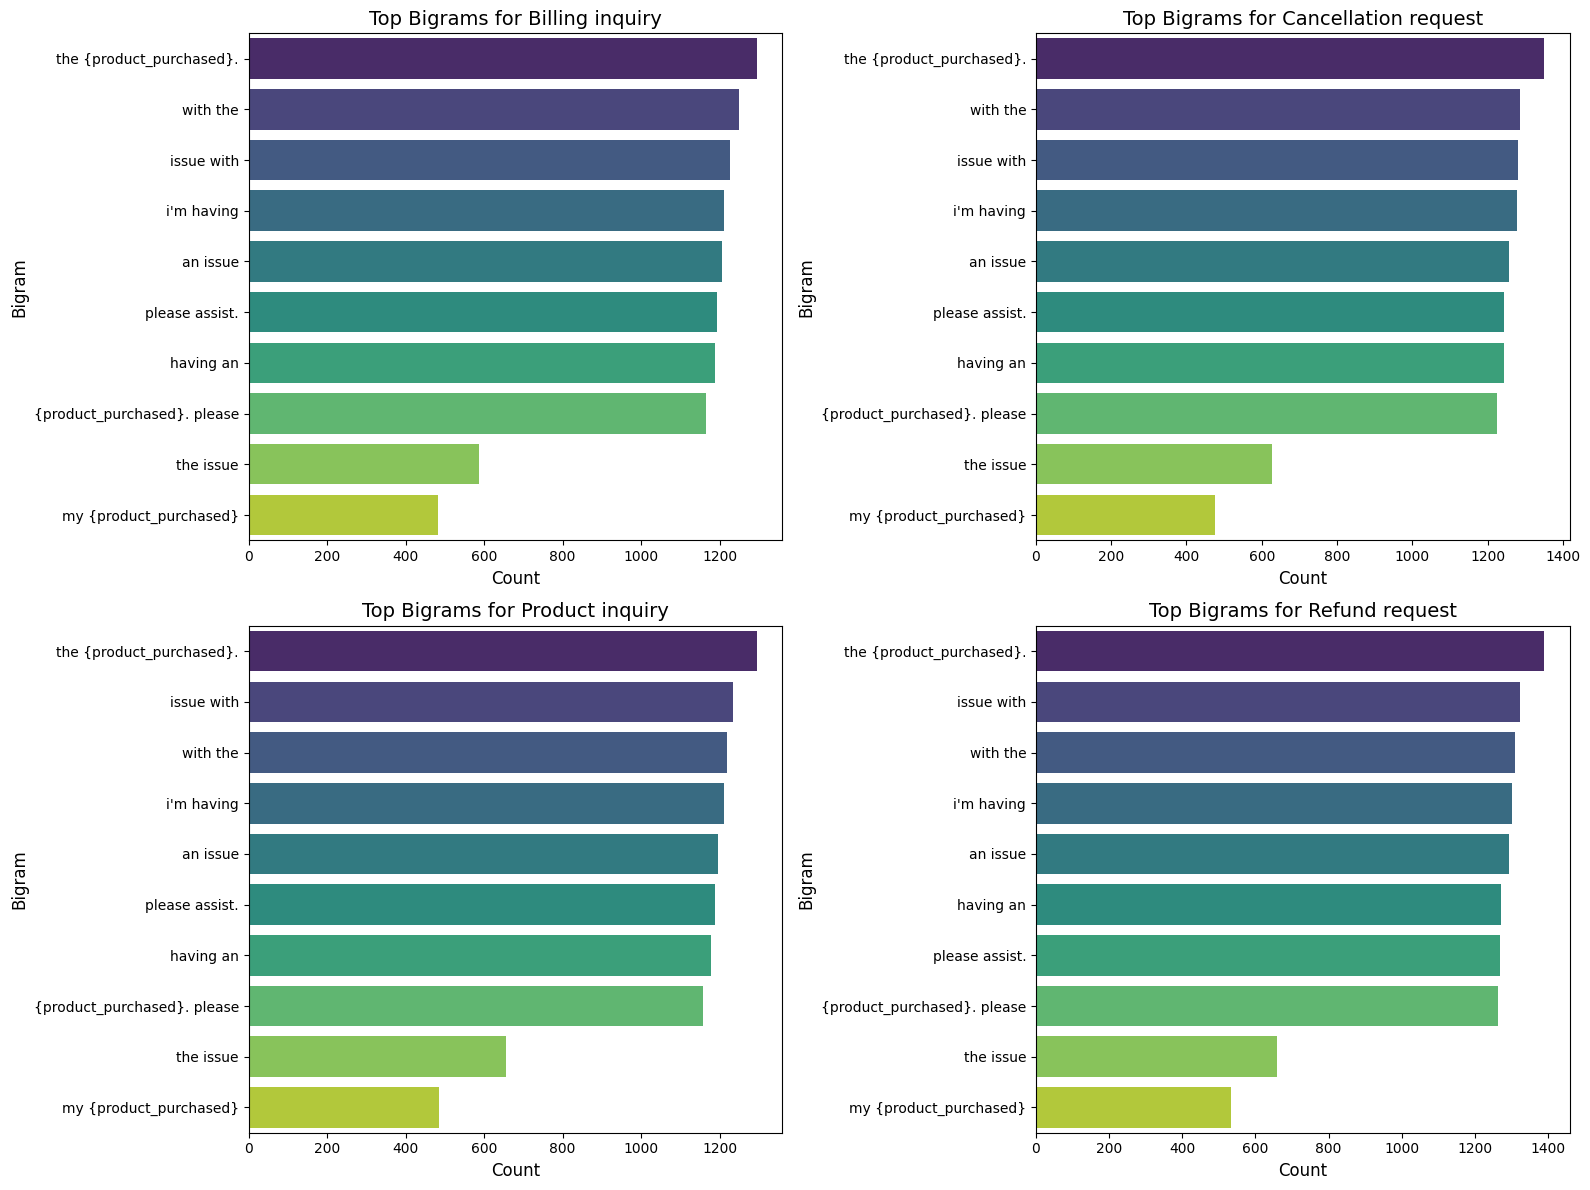

In [30]:
# Plot for the Bigram Words 
plot_data = []
for ticket_type, words in top_words_by_type.items():
    for word, count in words['bigrams']:
        plot_data.append({'Ticket Type': ticket_type, 'Word': ' '.join(word), 'Count': count})

top_words_df = pd.DataFrame(plot_data)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (ticket_type, group) in enumerate(top_words_df.groupby('Ticket Type')):
    if i >= min(len(top_words_df['Ticket Type'].unique()), len(axes)):
        break
    group_sorted = group.sort_values(by='Count', ascending=False)
    sns.barplot(x='Count', y='Word', data=group_sorted, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top Bigrams for {ticket_type}', fontsize=14)
    axes[i].set_xlabel('Count', fontsize=12)
    axes[i].set_ylabel('Bigram', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'eda_thiruvelap_topbigrams_by_tickettype.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'eda_thiruvelap_fig_24.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: eda_thiruvelap_fig_24.png")

plt.show()

C:\Users\96321\AppData\Local\Temp\ipykernel_23564\3724474442.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=group_sorted, ax=axes[i], palette='viridis')
C:\Users\96321\AppData\Local\Temp\ipykernel_23564\3724474442.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=group_sorted, ax=axes[i], palette='viridis')
C:\Users\96321\AppData\Local\Temp\ipykernel_23564\3724474442.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=group_sorted, ax=axes[i], palette='vi

Saved figure: eda_thiruvelap_fig_25.png


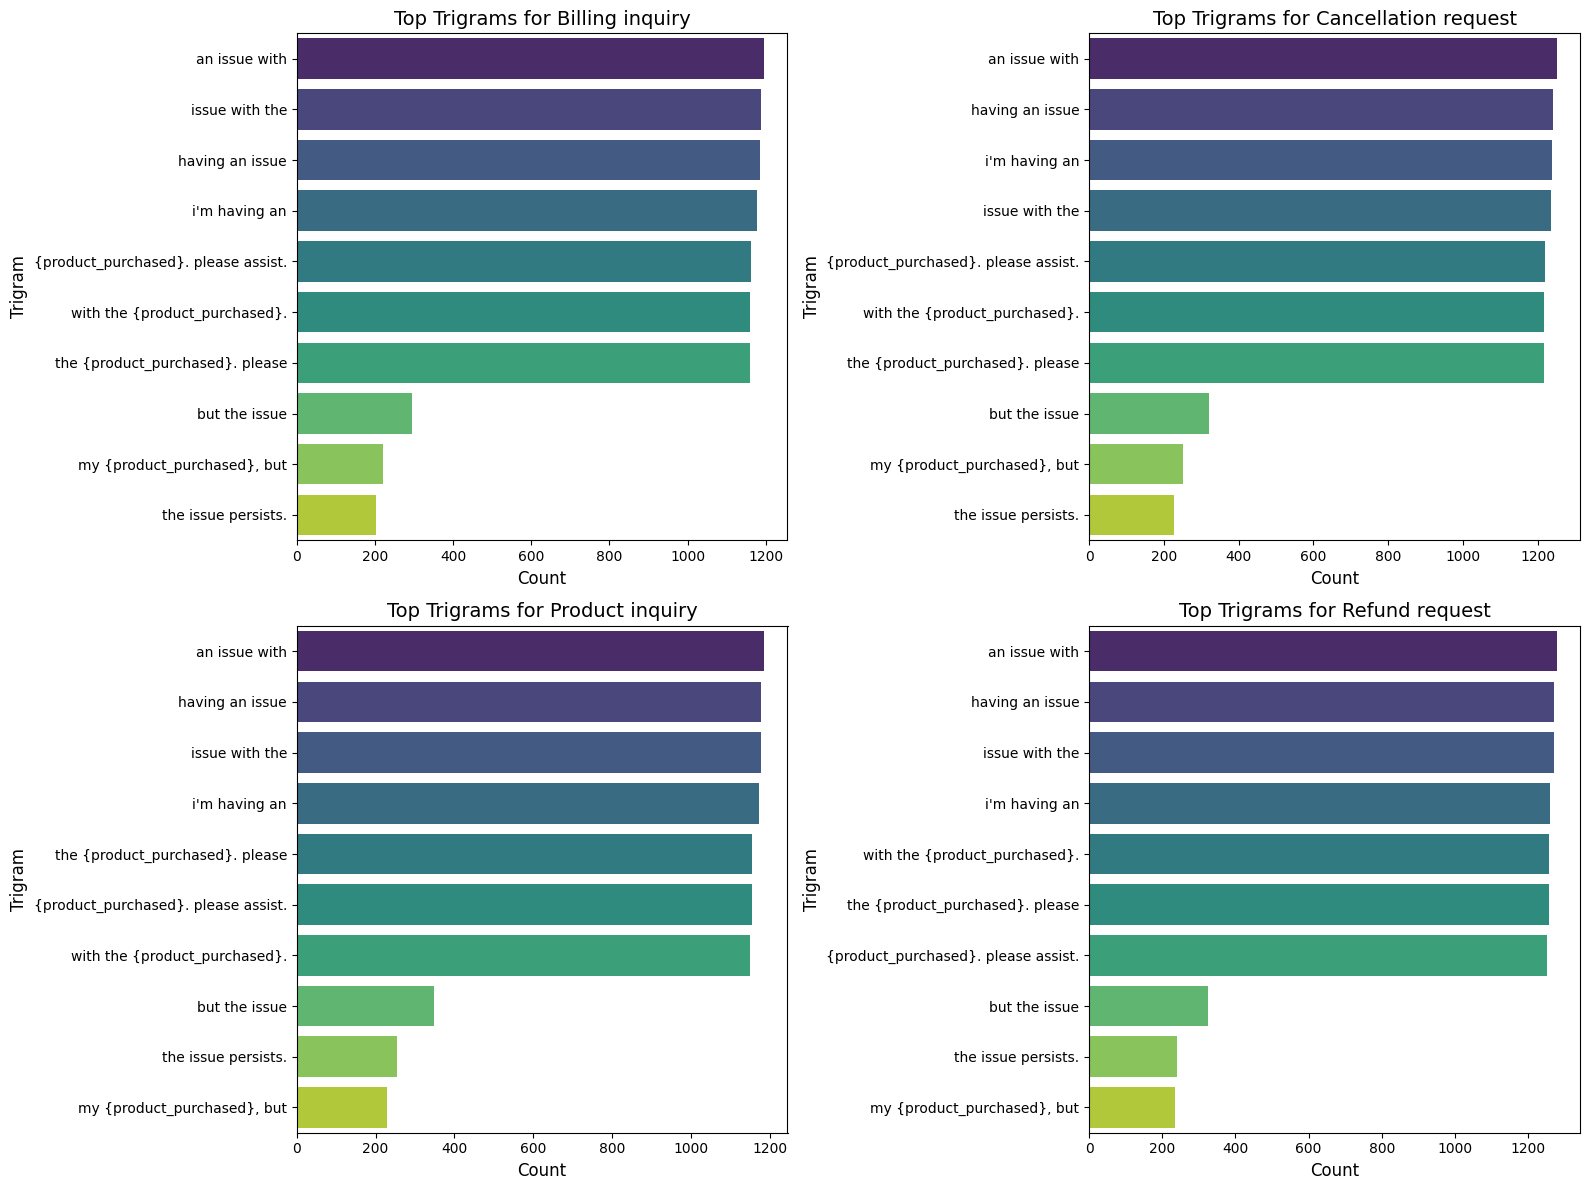

In [31]:
# Plot for the Trigram Words
plot_data = []
for ticket_type, words in top_words_by_type.items():
    for word, count in words['trigrams']:
        plot_data.append({'Ticket Type': ticket_type, 'Word': ' '.join(word), 'Count': count})

top_words_df = pd.DataFrame(plot_data)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (ticket_type, group) in enumerate(top_words_df.groupby('Ticket Type')):
    if i >= min(len(top_words_df['Ticket Type'].unique()), len(axes)):
        break
    group_sorted = group.sort_values(by='Count', ascending=False)
    sns.barplot(x='Count', y='Word', data=group_sorted, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top Trigrams for {ticket_type}', fontsize=14)
    axes[i].set_xlabel('Count', fontsize=12)
    axes[i].set_ylabel('Trigram', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'eda_thiruvelap_toptrigrams_by_tickettype.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'eda_thiruvelap_fig_25.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: eda_thiruvelap_fig_25.png")

plt.show()

#### Key Findings & Numbers:

-  "Templated" Ticket Descriptions:
    *   Every single ticket (100%) uses a placeholder like `{product_purchased}`. This suggests many descriptions are automatically generated or follow a strict template.
    *   This templated language makes common words (like 'issue', '{product_purchased}', 'having') and phrases (like 'an issue with', 'i'm having an') appear very frequently across *all* ticket types. It's hard to tell specific problems from general complaints.

-   "Noisy" Text Data:
    *   About 203 tickets contain social media handles (like '@username').
    *   14 tickets include ZIP codes.
    *   These are small bits of irrelevant information that need to be cleaned out if we want to use the text for advanced analysis.

-   Ticket Categories are Balanced:
    *   The number of tickets for different `Ticket Types` (like Technical, Billing, Refund) is very even, with about 1600-1700 tickets in each category.
    *   Similarly, how customers contact us (`Ticket Channel` - Email, Phone, Chat, Social Media) is also very balanced.
    *   This means there isn't one type of issue or contact method that dominates heavily.

-   Average Ticket Length:
    *   Ticket descriptions are typically around 46 words long.
    *   The complexity of language (unique words vs. repeated words) is similar across all ticket types.